# Урок 3.1. Бэггинг и случайный лес

**Интерактивная версия:** `lessons/lesson_3_1/web/index.html`

1. Бутстрэп: доля уникальных объектов → $1 - 1/e$.
2. Бэггинг и OOB-оценка.
3. Случайный лес: max_features, корреляция и качество.
4. Сверка с scikit-learn.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from gbcourse import datasets, BaggingTrees, Mulberry32
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Бутстрэп

In [2]:
rng = Mulberry32(0)
for n in (10, 100, 1000, 10000):
    share = np.mean([len(set(rng.bootstrap(n))) / n for _ in range(200)])
    print(f"n = {n:5d}: доля уникальных {share:.4f}  (теория {1 - (1 - 1 / n) ** n:.4f}, предел {1 - np.exp(-1):.4f})")

n =    10: доля уникальных 0.6480  (теория 0.6513, предел 0.6321)
n =   100: доля уникальных 0.6333  (теория 0.6340, предел 0.6321)
n =  1000: доля уникальных 0.6314  (теория 0.6323, предел 0.6321)


n = 10000: доля уникальных 0.6321  (теория 0.6321, предел 0.6321)


## 2. Бэггинг и OOB

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


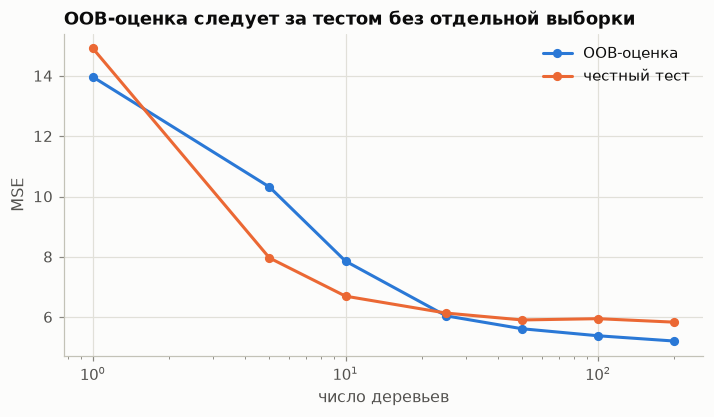

In [3]:
X, y = datasets.friedman1(n=300, noise=1.0, seed=31)
X_te, y_te = datasets.friedman1(n=1000, noise=1.0, seed=32)
Bs = [1, 5, 10, 25, 50, 100, 200]
bag = BaggingTrees(n_estimators=200, max_depth=None, seed=0).fit(X, y)
oob_curve, test_curve = [], []
for B in Bs:
    sub = BaggingTrees(n_estimators=B, max_depth=None, seed=0)
    sub.trees_, sub.inbag_counts_ = bag.trees_[:B], bag.inbag_counts_[:B]
    oob = sub.oob_predict(X)
    ok = ~np.isnan(oob)
    oob_curve.append(mse(y[ok], oob[ok]))
    test_curve.append(mse(y_te, sub.predict(X_te)))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(Bs, oob_curve, marker="o", label="OOB-оценка")
ax.plot(Bs, test_curve, marker="o", label="честный тест")
ax.set_xscale("log")
ax.set(xlabel="число деревьев", ylabel="MSE", title="OOB-оценка следует за тестом без отдельной выборки")
ax.legend()
plt.show()

## 3. Случайный лес: доля признаков в узле

In [4]:
rows = []
for mf in (0.1, 0.2, 0.3, 0.5, 0.7, 1.0):
    rf = BaggingTrees(n_estimators=50, max_depth=None, max_features=mf, seed=1).fit(X, y)
    P = np.array([t.predict(X_te) for t in rf.trees_])
    C = np.corrcoef(P)
    rho = C[np.triu_indices_from(C, k=1)].mean()
    rows.append({"max_features": mf, "корреляция ρ": rho, "MSE дерева": np.mean([mse(y_te, p) for p in P]),
                 "MSE леса": mse(y_te, P.mean(0))})
pd.DataFrame(rows).round(3)

,max_features,корреляция ρ,MSE дерева,MSE леса
0,0.1,0.203,28.543,10.310
1,0.2,0.340,22.334,7.342
2,0.3,0.478,17.987,6.207
3,0.5,0.588,15.113,5.847
4,0.7,0.638,14.019,5.817
5,1.0,0.664,13.442,5.811


## 4. То же в scikit-learn

In [5]:
for mf in (1.0, 0.3):
    rf = RandomForestRegressor(n_estimators=300, max_features=mf, oob_score=True, random_state=0).fit(X, y)
    print(f"sklearn max_features={mf}: OOB R² {rf.oob_score_:.3f}, тест MSE {mse(y_te, rf.predict(X_te)):.3f}")

sklearn max_features=1.0: OOB R² 0.783, тест MSE 5.811


sklearn max_features=0.3: OOB R² 0.774, тест MSE 6.072


## Упражнения

1. Сравните OOB-оценку с 5-fold кросс-валидацией леса по времени и точности.
2. Какая доля признаков лучшая для классификации на `classification_2d("spiral")`? Почему там всего 2 варианта?
3. Обучите лес с `max_depth=3`. Помогает ли усреднение неглубоким деревьям? Сравните с бустингом той же глубины.

Решения: `python lessons/lesson_3_1/exercises/solutions.py`.